In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

# Scaled data load karo
df = pd.read_csv("../data/diabetes_cleaned.csv")

print("Shape:", df.shape)
df.head()

Shape: (96146, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,1,-0.317475,0.994563,0.043554,0
1,0,0.543372,0,0,0,0.007649,0.994563,-1.423096,0
2,1,-0.614096,0,0,1,0.007649,0.155970,0.483549,0
3,0,-0.257952,0,0,5,-0.583069,-0.496269,0.410216,0
4,1,1.522768,1,1,5,-1.088309,-0.682623,0.410216,0


In [ ]:
# FEATURE ENGINEERING

# Note: Data already scaled hai
# Isliye engineered features bhi scaled values pe banenge

# 1. Risk Score — kitne risk factors hain
df['risk_score'] = (
    df['hypertension'] +
    df['heart_disease'] +
    (df['smoking_history'] >= 4).astype(int) +  # current/not current
    (df['bmi'] >= 0).astype(int) +               # scaled mein 0 = ~27 BMI (overweight)
    (df['age'] >= 0).astype(int)                 # scaled mein 0 = ~42 age
)

# 2. Blood Sugar Risk
# Scaled mein HbA1c >= 0.9 ~ 6.5 (diabetic range)
# Scaled mein glucose >= 0.5 ~ 158 (high range)
df['blood_sugar_risk'] = (
    (df['HbA1c_level'] >= 0.9).astype(int) +
    (df['blood_glucose_level'] >= 0.5).astype(int)
)

# 3. Age-Hypertension Interaction
# Older + Hypertensive = high risk combination
df['age_hypertension'] = df['age'] * df['hypertension']

# 4. BMI-Glucose Interaction
# High BMI + High Glucose = strong diabetes indicator
df['bmi_glucose'] = df['bmi'] * df['blood_glucose_level']

print("Feature Engineering done!")
print(df[['risk_score', 'blood_sugar_risk',
          'age_hypertension', 'bmi_glucose']].head())
print("\nNew Shape:", df.shape)

Feature Engineering done!
   risk_score  blood_sugar_risk  age_hypertension  bmi_glucose
0           2                 1          0.000000    -0.013827
1           2                 1          0.000000    -0.010885
2           1                 0         -0.000000     0.003699
3           1                 0         -0.000000    -0.239185
4           4                 0          1.522768    -0.446442

New Shape: (96146, 13)


Correlation with Diabetes:
diabetes               1.000000
blood_glucose_level    0.424336
HbA1c_level            0.406408
blood_sugar_risk       0.378196
risk_score             0.279196
age                    0.264927
bmi_glucose            0.247577
bmi                    0.215706
hypertension           0.195710
age_hypertension       0.182479
heart_disease          0.170711
smoking_history        0.077899
gender                 0.037613
Name: diabetes, dtype: float64


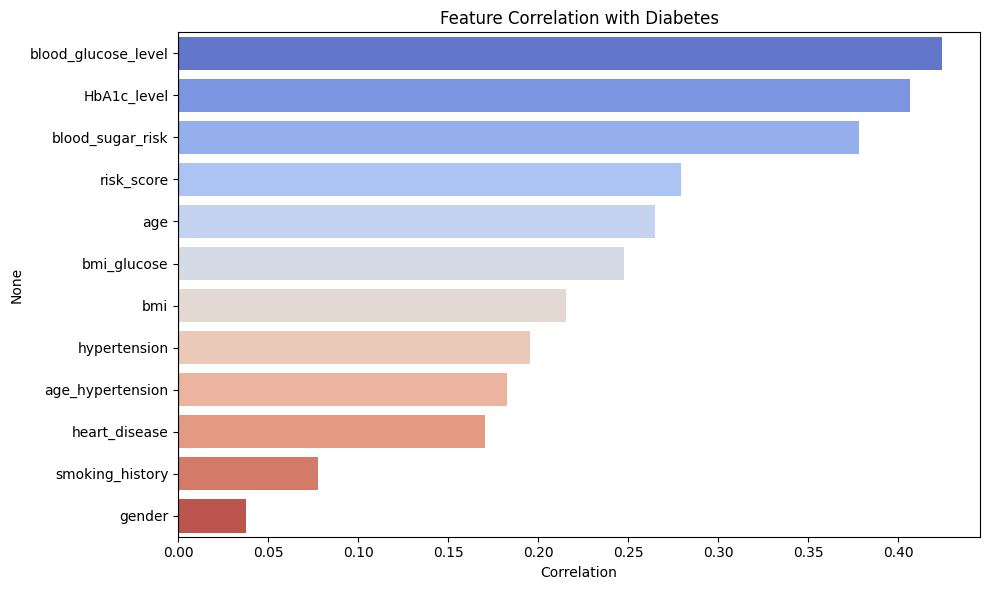

In [3]:
# CORRELATION WITH TARGET

correlation = df.corr()['diabetes'].sort_values(ascending=False)
print("Correlation with Diabetes:")
print(correlation)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    x=correlation.drop('diabetes').values,
    y=correlation.drop('diabetes').index,
    hue=correlation.drop('diabetes').index,
    palette='coolwarm',
    legend=False
)
plt.title('Feature Correlation with Diabetes')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [5]:
# FEATURE SELECTION

# gender drop — near zero correlation
features = [
    'blood_glucose_level',
    'HbA1c_level',
    'blood_sugar_risk',
    'risk_score',
    'age',
    'bmi_glucose',
    'bmi',
    'hypertension',
    'age_hypertension',
    'heart_disease',
    'smoking_history'
]

X = df[features]
y = df['diabetes']

print("Features:", features)
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())


Features: ['blood_glucose_level', 'HbA1c_level', 'blood_sugar_risk', 'risk_score', 'age', 'bmi_glucose', 'bmi', 'hypertension', 'age_hypertension', 'heart_disease', 'smoking_history']
X shape: (96146, 11)
y distribution:
 diabetes
0    87664
1     8482
Name: count, dtype: int64


In [6]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size :", X_test.shape)
print("\nBefore SMOTE:")
print(y_train.value_counts())


Train size: (76916, 11)
Test size : (19230, 11)

Before SMOTE:
diabetes
0    70130
1     6786
Name: count, dtype: int64


In [7]:
# SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())


After SMOTE:
diabetes
0    70130
1    70130
Name: count, dtype: int64


In [8]:
# MODELS

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'        : GaussianNB(),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    # 'SVM'                : SVC(probability=True, random_state=42)
}

results = []

In [9]:
# MODELS (except SVM)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'        : GaussianNB(),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
}

results = []

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'AUC Score': round(roc_auc_score(y_test, y_prob), 4)
    })
    print(f"{name} done ")

Logistic Regression done 
Decision Tree done 
Random Forest done 
Naive Bayes done 
KNN done 


In [10]:
# RESULTS TABLE

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("\n", results_df)


                  Model  Accuracy  Precision  Recall  F1 Score  AUC Score
0        Random Forest    0.9573     0.7614  0.7506    0.7559     0.9626
1        Decision Tree    0.9453     0.6689  0.7518    0.7079     0.8589
2                  KNN    0.9069     0.4835  0.8131    0.6064     0.9148
3  Logistic Regression    0.8810     0.4173  0.8821    0.5666     0.9618
4          Naive Bayes    0.8778     0.3969  0.7412    0.5170     0.9084


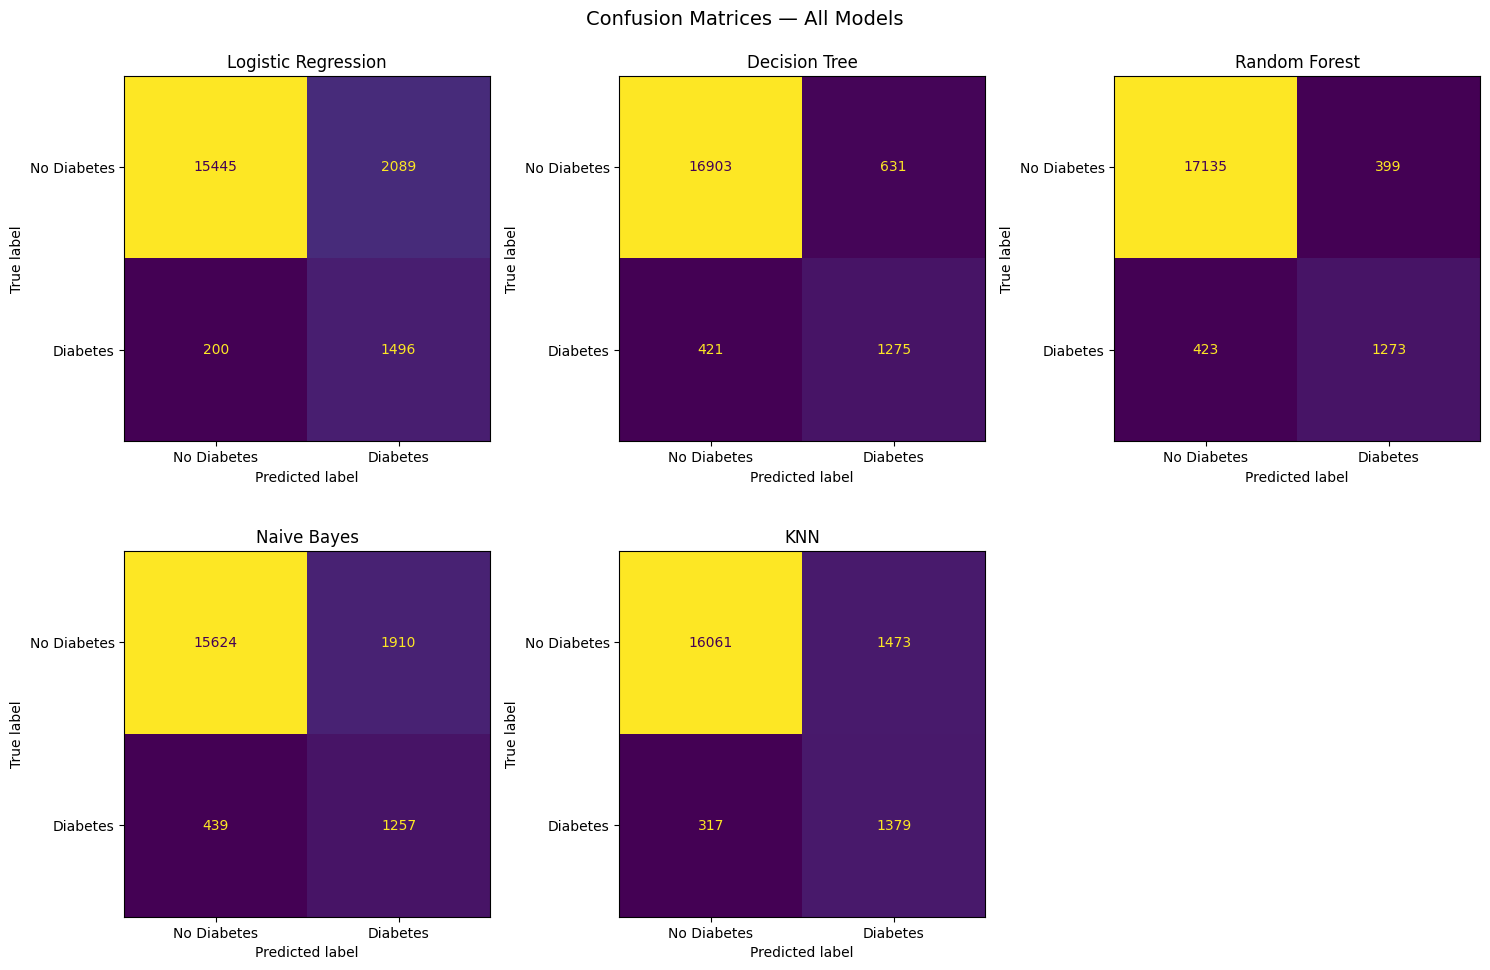

In [11]:
# CONFUSION MATRICES

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)

# Last subplot hide karo — 5 models hain, 6 slots hain
axes[5].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# MODELS SAVE

import joblib

for name, model in models.items():
    filename = name.lower().replace(' ', '_')
    joblib.dump(model, f'../models/{filename}_model.pkl')
    print(f"{name} saved ✅")